# Day 6: Advanced Analytics & Risk Metrics
This notebook implements Day 6 tasks from the Bluestock Capstone Handbook:
- 95% Historical Value at Risk (VaR) & Conditional VaR (CVaR)
- Investor Cohort Analysis by initial transaction year
- SIP Continuation Analysis flagging at-risk investors (>35 days gap)
- Multi-Factor Fund Recommendation Model
- Sector Concentration Analysis (Herfindahl-Hirschman Index - HHI)

In [1]:
import sqlite3
import sys

import seaborn as sns
from IPython.display import Image, display

sys.path.append('../scripts')

from cohort_analysis import (
    run_cohort_analysis,
    run_sector_hhi_analysis,
    run_sip_continuation_analysis,
    run_var_cvar_analysis,
)
from recommender import recommend_funds

sns.set_theme(style='whitegrid')
print('Advanced Analytics Environment Initialized.')

Advanced Analytics Environment Initialized.


## 1. Value at Risk (VaR) and Conditional VaR (CVaR)
Historical 95% VaR measures the 5th percentile worst daily return. CVaR (Expected Shortfall) measures the expected loss beyond the VaR threshold.

In [2]:
conn = sqlite3.connect('../mutual_fund_analytics.db')
df_var = run_var_cvar_analysis(conn)
display(df_var.sort_values('var_95_pct', ascending=True).head(10))

[2026-07-29 23:00:46] [INFO] [cohort_analysis] Executing VaR & CVaR Analysis...


[2026-07-29 23:00:46] [INFO] [cohort_analysis] VaR/CVaR Report written to /Users/ruthvikgoud/Music/mutual-fund-analytics-Bluestock/reports/var_cvar_report.csv


,amfi_code,scheme_name,category,var_95_pct,cvar_95_pct
4,101207,ABSL Small Cap Fund - Regular - Growth,Equity,-2.3906,-3.0289
17,119095,Axis Small Cap Fund - Regular - Growth,Equity,-2.3272,-2.9690
22,119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,-2.3155,-3.0163
11,118634,Nippon India Small Cap Fund - Regular - Growth,Equity,-2.2806,-2.9940
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,-2.1519,-2.8573
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-2.1469,-2.8444
16,119094,Axis Midcap Fund - Regular - Growth,Equity,-1.6990,-2.2375
29,120842,Kotak Emerging Equity Fund - Regular - Growth,Equity,-1.6948,-2.1251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,-1.6898,-2.1850
7,102886,UTI Mid Cap Fund - Regular - Growth,Equity,-1.6857,-2.1771


## 2. 90-Day Rolling Sharpe Ratio Time Series
Evaluating rolling risk-adjusted performance dynamics.

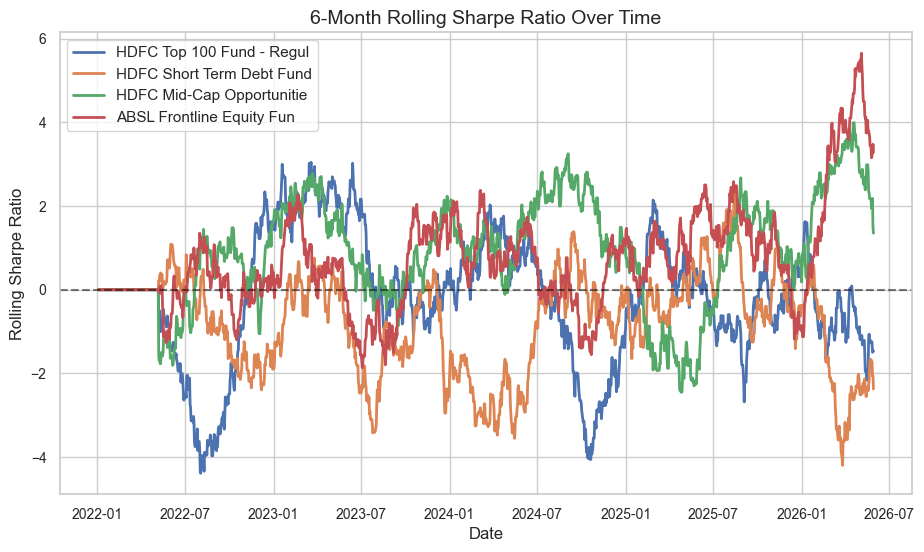

In [3]:
display(Image(filename='../figures/risk_metrics/02_rolling_sharpe.png'))

## 3. Investor Cohorts & SIP Continuation Analysis
Tracking investor retention and identifying at-risk accounts with inter-transaction gaps > 35 days.

In [4]:
df_cohort = run_cohort_analysis(conn)
display(df_cohort)

df_continuity = run_sip_continuation_analysis(conn)
print(f'Total Active SIP Investors Evaluated: {len(df_continuity)}')
print(f'At-Risk Investors Flagged (>35 days gap): {len(df_continuity[df_continuity["status"] == "at-risk"])}')
display(df_continuity.head(10))

[2026-07-29 23:00:46] [INFO] [cohort_analysis] Executing Investor Cohort Analysis...


[2026-07-29 23:00:46] [INFO] [cohort_analysis] Cohort Analysis written to /Users/ruthvikgoud/Music/mutual-fund-analytics-Bluestock/reports/cohort_analysis.csv


,cohort_year,total_investors,total_transactions,total_invested_inr,avg_sip_amount_inr,median_sip_amount_inr,preferred_amfi_code,preferred_scheme_name
0,2024,4803,32499,3.491125e+09,10996.885825,5131.0,148568,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,197,279,3.045524e+07,13505.209581,6240.0,120507,ICICI Pru Liquid Fund - Regular - Growth


[2026-07-29 23:00:46] [INFO] [cohort_analysis] Executing SIP Continuation Analysis...


[2026-07-29 23:00:46] [INFO] [cohort_analysis] SIP Continuation Analysis written to /Users/ruthvikgoud/Music/mutual-fund-analytics-Bluestock/reports/sip_continuity.csv


Total Active SIP Investors Evaluated: 1362
At-Risk Investors Flagged (>35 days gap): 1358


,investor_id,sip_count,avg_gap_days,max_gap_days,status,last_sip_date
0,INV000004,6,85.40,265,at-risk,2025-05-17
1,INV000008,6,70.40,165,at-risk,2025-05-14
2,INV000010,6,64.80,139,at-risk,2025-03-01
3,INV000011,7,40.17,125,at-risk,2024-08-31
4,INV000012,8,57.00,132,at-risk,2025-04-30
5,INV000013,7,55.33,104,at-risk,2025-03-16
6,INV000014,7,75.33,128,at-risk,2025-05-20
7,INV000023,8,58.57,115,at-risk,2025-05-05
8,INV000028,6,93.60,238,at-risk,2025-05-20
9,INV000029,7,60.67,96,at-risk,2025-05-15


## 4. Multi-Factor Fund Recommendation Model
Recommending top 3 funds per risk category based on Sharpe ratio, CAGR, and downside risk.

In [5]:
for risk_profile in ['Low', 'Moderate', 'High']:
    print(f'=== Recommendations for {risk_profile} Risk Profile ===')
    display(recommend_funds(risk_profile, top_n=3, db_path='../mutual_fund_analytics.db'))

=== Recommendations for Low Risk Profile ===


,rank,amfi_code,scheme_name,category,risk_category,sharpe_ratio,cagr_pct,volatility_ann_pct,sortino_ratio
0,1,120507,ICICI Pru Liquid Fund - Regular - Growth,Debt,Low,2.69,7.24,0.46,3.72
1,2,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Moderate,2.08,30.97,12.02,3.14
2,3,120844,Kotak Liquid Fund - Regular - Growth,Debt,Low,1.94,6.92,0.47,2.63


=== Recommendations for Moderate Risk Profile ===


,rank,amfi_code,scheme_name,category,risk_category,sharpe_ratio,cagr_pct,volatility_ann_pct,sortino_ratio
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Moderate,2.08,30.97,12.02,3.14
1,2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,Moderately High,1.85,30.91,13.45,2.87
2,3,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Moderate,1.70,25.80,11.63,2.60


=== Recommendations for High Risk Profile ===


,rank,amfi_code,scheme_name,category,risk_category,sharpe_ratio,cagr_pct,volatility_ann_pct,sortino_ratio
0,1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,High,1.73,31.95,14.96,2.64
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,High,1.64,32.83,16.33,2.49
2,3,149323,DSP Midcap Fund - Regular - Growth,Equity,High,1.57,29.58,15.02,2.32


## 5. Sector Concentration Analysis (HHI)
Evaluating Herfindahl-Hirschman Index (HHI) across fund portfolios.

[2026-07-29 23:00:46] [INFO] [cohort_analysis] Executing Sector HHI Analysis...


[2026-07-29 23:00:46] [INFO] [cohort_analysis] Sector HHI Analysis written to /Users/ruthvikgoud/Music/mutual-fund-analytics-Bluestock/reports/sector_hhi.csv


,amfi_code,scheme_name,hhi_sector,diversification_score,num_sectors,top_sector,concentration_level
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1805.88,93.65,8,IT,Moderate
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,2276.47,90.11,7,Banking,Moderate
2,101206,ABSL Frontline Equity Fund - Regular - Growth,1800.42,95.66,7,Banking,Moderate
3,101207,ABSL Small Cap Fund - Regular - Growth,2227.27,93.27,6,Pharma,Moderate
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,1807.12,93.63,8,Utilities,Moderate
5,102886,UTI Mid Cap Fund - Regular - Growth,1240.20,97.33,10,Consumer Goods,Low
6,102887,UTI Flexi Cap Fund - Regular - Growth,2513.83,89.83,6,Pharma,High
7,118632,Nippon India Large Cap Fund - Regular - Growth,2072.59,95.13,6,Telecom,Moderate
8,118633,Nippon India Large Cap Fund - Direct - Growth,2212.00,90.86,7,Banking,Moderate
9,118634,Nippon India Small Cap Fund - Regular - Growth,1602.99,95.97,8,FMCG,Moderate


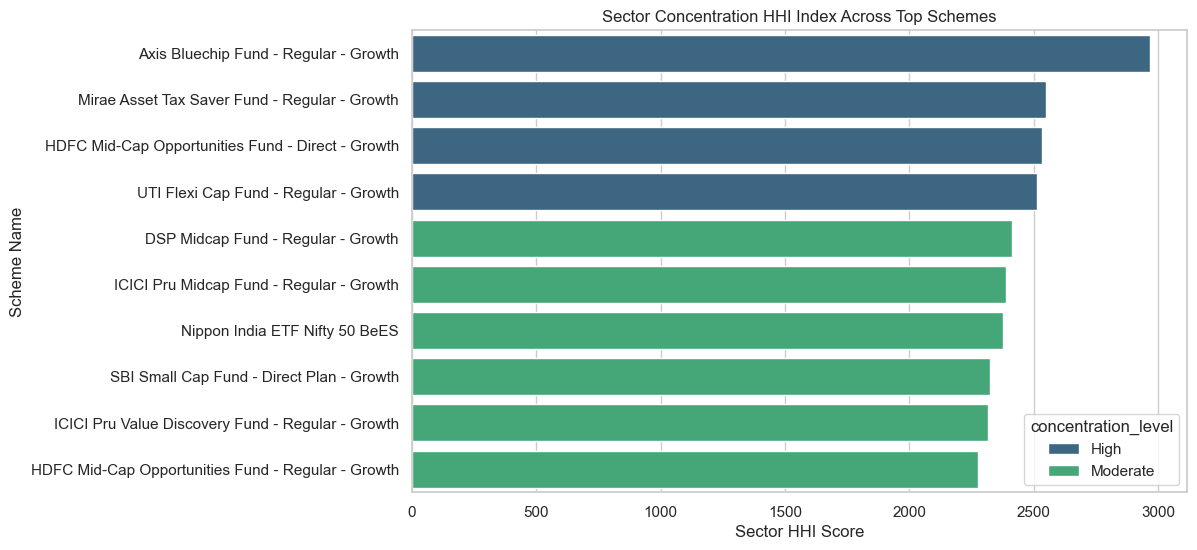

In [6]:
df_hhi = run_sector_hhi_analysis(conn)
display(df_hhi.head(10))
display(Image(filename='../figures/sector_hhi_chart.png'))
conn.close()